# Sentiment Analysis of Product Reviews

This project performs sentiment classification on Amazon product reviews using traditional machine learning and transformer-based NLP models.

In [ ]:
import pandas as pd

# load dataset 
df = pd.read_csv("Reviews.csv")


In [3]:
# -----------------------------------
# Create Sentiment Column
# -----------------------------------

def get_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df['Sentiment'] = df['Score'].apply(get_sentiment)

# check result
print(df[['Score', 'Sentiment']].head())

   Score Sentiment
0      5  Positive
1      1  Negative
2      4  Positive
3      2  Negative
4      5  Positive


In [4]:
df = df.sample(20000, random_state=42)

## Data Preprocessing

Text preprocessing was performed to improve model performance by removing noise and converting text into a standardized format.

The preprocessing steps included:
- Lowercasing text
- Removing special characters
- Removing stopwords
- Cleaning unnecessary symbols

In [5]:
# -----------------------------------
# Text Cleaning
# -----------------------------------
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()                  # lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)    # remove symbols/numbers
    words = text.split()
    words = [word for word in words if word not in stop_words]  # remove stopwords
    return " ".join(words)

df['Cleaned_Text'] = df['Text'].apply(clean_text)

# check
print(df[['Text', 'Cleaned_Text']].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kiran\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                     Text  \
165256  Having tried a couple of other brands of glute...   
231465  My cat loves these treats. If ever I can't fin...   
427827  A little less than I expected.  It tends to ha...   
433954  First there was Frosted Mini-Wheats, in origin...   
70260   and I want to congratulate the graphic artist ...   

                                             Cleaned_Text  
165256  tried couple brands gluten free sandwich cooki...  
231465  cat loves treats ever find house pop top bolts...  
427827  little less expected tends muddy taste expecte...  
433954  first frosted mini wheats original size froste...  
70260   want congratulate graphic artist putting entir...  


In [6]:
# -----------------------------------
# Feature Engineering (TF-IDF)
# -----------------------------------
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['Cleaned_Text'])   # features
y = df['Sentiment']                           # target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data ready for model")

Data ready for model


In [7]:
# -----------------------------------
# Model Building - SVM
# -----------------------------------
from sklearn.svm import LinearSVC

# create model
model = LinearSVC()

# train model
model.fit(X_train, y_train)

print("Model training completed")
# save model
import pickle

pickle.dump(model, open("svm_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))

Model training completed


In [8]:
# make predictions
y_pred = model.predict(X_test)

print(y_pred[:10])

['Positive' 'Negative' 'Positive' 'Positive' 'Positive' 'Positive'
 'Negative' 'Positive' 'Positive' 'Positive']


In [9]:
# -----------------------------------
# Model Evaluation
# -----------------------------------
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.82975

Classification Report:

              precision    recall  f1-score   support

    Negative       0.66      0.56      0.61       581
     Neutral       0.32      0.14      0.19       317
    Positive       0.88      0.95      0.91      3102

    accuracy                           0.83      4000
   macro avg       0.62      0.55      0.57      4000
weighted avg       0.80      0.83      0.81      4000


Confusion Matrix:

[[ 327   44  210]
 [  66   43  208]
 [ 106   47 2949]]


In [10]:
# -----------------------------------
# BERT (DistilBERT) Model
# -----------------------------------
from transformers import pipeline

# load pretrained sentiment model
bert_model = pipeline("sentiment-analysis")

# test on few samples (DON'T run on full dataset - too slow)
sample_texts = df['Text'].head(20).tolist()

bert_predictions = []

for text in sample_texts:
    result = bert_model(text[:512])[0]   # limit length
    bert_predictions.append(result['label'])

print(bert_predictions)

c:\Users\kiran\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2820.48it/s]


['POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEGATIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE']


In [11]:
from transformers import pipeline
from sklearn.metrics import accuracy_score

# load model
bert_model = pipeline("sentiment-analysis")

# take sample (small for speed)
sample_df = df.sample(500, random_state=42)

bert_preds = []
true_labels = []

for _, row in sample_df.iterrows():
    text = row['Text'][:512]
    result = bert_model(text)[0]['label']

    # convert labels
    if result == "POSITIVE":
        pred = "Positive"
    else:
        pred = "Negative"

    # ignore neutral
    if row['Sentiment'] != "Neutral":
        bert_preds.append(pred)
        true_labels.append(row['Sentiment'])

# accuracy
bert_acc = accuracy_score(true_labels, bert_preds)

print("BERT Accuracy:", bert_acc)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2897.25it/s]


BERT Accuracy: 0.8675213675213675


In [12]:
print("SVM Accuracy:", accuracy)
print("BERT Accuracy:", bert_acc)

SVM Accuracy: 0.82975
BERT Accuracy: 0.8675213675213675


In [13]:
# -----------------------------------
# Create Product Categories
# -----------------------------------

def get_category(text):
    text = text.lower()
    
    if "dog" in text or "pet" in text:
        return "Pet Food"
    elif "coffee" in text or "tea" in text:
        return "Beverages"
    elif "chocolate" in text or "snack" in text:
        return "Snacks"
    elif "vitamin" in text or "health" in text:
        return "Health"
    else:
        return "Other"

df['Category'] = df['Text'].apply(get_category)

print(df['Category'].value_counts())

Category
Other        10235
Beverages     4805
Pet Food      2112
Snacks        1891
Health         957
Name: count, dtype: int64


In [14]:
from sklearn.metrics import accuracy_score

category_results = {}

for category in df['Category'].unique():
    temp_df = df[df['Category'] == category]

    if len(temp_df) > 50:   # avoid small groups
        X_temp = tfidf.transform(temp_df['Cleaned_Text'])
        y_temp = temp_df['Sentiment']

        y_pred_temp = model.predict(X_temp)

        acc = accuracy_score(y_temp, y_pred_temp)
        category_results[category] = acc

print(category_results)

{'Snacks': 0.9301956636700158, 'Other': 0.9047386419149975, 'Beverages': 0.9123829344432882, 'Pet Food': 0.9171401515151515, 'Health': 0.9164054336468129}


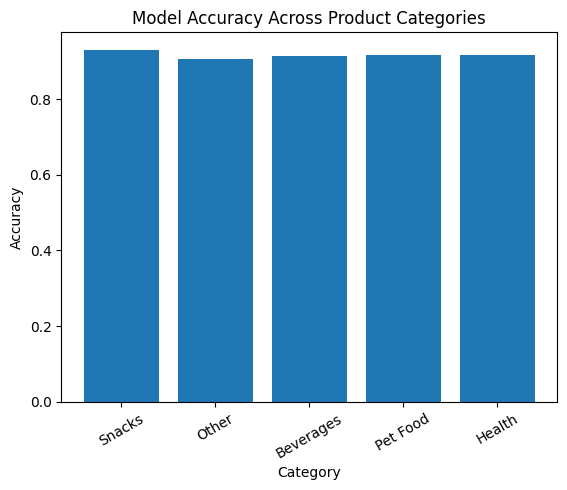

In [15]:
import matplotlib.pyplot as plt

categories = list(category_results.keys())
accuracies = list(category_results.values())

plt.bar(categories, accuracies)
plt.title("Model Accuracy Across Product Categories")
plt.xlabel("Category")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()